In [1]:
import pandas as pd

In [2]:
df= pd.read_csv(r"D:\OneDrive\Desktop\Financial_Fraud_detection_project\synthetic_fraud_dataset1.csv")

In [3]:
df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Date,Account_Balance,Device_Type,Location,Merchant_Category,Previous_Fraudulent_Activity,Daily_Transaction_Count,Card_Type,Card_Age,Fraud_Label
0,TXN_33553,USER_1834,39.79,POS,14-Aug-23,93213.17,Laptop,Sydney,Travel,0,7,Amex,65,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,07-Jun-23,75725.25,Mobile,New York,Clothing,0,13,Mastercard,186,1
2,TXN_199,USER_2734,28.96,Online,20-Jun-23,1588.96,Tablet,Mumbai,Restaurants,0,14,Visa,226,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,07-Dec-23,76807.20,Tablet,New York,Clothing,0,8,Visa,76,1
4,TXN_39489,USER_2014,31.28,POS,11-Nov-23,92354.66,Mobile,Mumbai,Electronics,1,14,Mastercard,140,1


In [4]:
print(df.shape)
print(df.columns)
df.info()

(50000, 14)
Index(['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type',
       'Date', 'Account_Balance', 'Device_Type', 'Location',
       'Merchant_Category', 'Previous_Fraudulent_Activity',
       'Daily_Transaction_Count', 'Card_Type', 'Card_Age', 'Fraud_Label'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Transaction_ID                50000 non-null  object 
 1   User_ID                       50000 non-null  object 
 2   Transaction_Amount            50000 non-null  float64
 3   Transaction_Type              50000 non-null  object 
 4   Date                          50000 non-null  object 
 5   Account_Balance               50000 non-null  float64
 6   Device_Type                   50000 non-null  object 
 7   Location                      50000 non-null  o

In [5]:
import os
print(os.getcwd())

C:\Users\piude\A


In [6]:
df.tail()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Date,Account_Balance,Device_Type,Location,Merchant_Category,Previous_Fraudulent_Activity,Daily_Transaction_Count,Card_Type,Card_Age,Fraud_Label
49995,TXN_11284,USER_4796,45.05,Online,29-Jan-23,76960.11,Mobile,Tokyo,Clothing,0,2,Amex,98,0
49996,TXN_44732,USER_1171,126.15,POS,09-May-23,28791.75,Mobile,Tokyo,Clothing,0,13,Visa,93,1
49997,TXN_38158,USER_2510,72.02,Online,30-Jan-23,29916.41,Laptop,Mumbai,Clothing,1,1,Visa,114,0
49998,TXN_860,USER_2248,64.89,Bank Transfer,09-Mar-23,67895.67,Mobile,Tokyo,Electronics,0,13,Discover,72,1
49999,TXN_15795,USER_6529,13.00,Bank Transfer,19-Aug-23,7668.82,Tablet,London,Restaurants,0,5,Mastercard,154,1


In [7]:
df.isnull().sum()

Transaction_ID                  0
User_ID                         0
Transaction_Amount              0
Transaction_Type                0
Date                            0
Account_Balance                 0
Device_Type                     0
Location                        0
Merchant_Category               0
Previous_Fraudulent_Activity    0
Daily_Transaction_Count         0
Card_Type                       0
Card_Age                        0
Fraud_Label                     0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df['Date'] = pd.to_datetime(df['Date'])

C:\Users\piude\AppData\Local\Temp\ipykernel_25088\2394721818.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


In [11]:
df['Date'].head()

0   2023-08-14
1   2023-06-07
2   2023-06-20
3   2023-12-07
4   2023-11-11
Name: Date, dtype: datetime64[ns]

In [12]:
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')

In [13]:
df['Date'].head()

0   2023-08-14
1   2023-06-07
2   2023-06-20
3   2023-12-07
4   2023-11-11
Name: Date, dtype: datetime64[ns]

In [14]:
df['Date'].isnull().sum()

0

In [15]:
df.to_csv("cleaned_fraud_data.csv", index=False)

In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Location'] = le.fit_transform(df['Location'])
df['Device_Type'] = le.fit_transform(df['Device_Type'])
df['Transaction_Type'] = le.fit_transform(df['Transaction_Type'])
df['Merchant_Category'] = le.fit_transform(df['Merchant_Category'])
df['Card_Type'] = le.fit_transform(df['Card_Type'])

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Transaction_ID                50000 non-null  object        
 1   User_ID                       50000 non-null  object        
 2   Transaction_Amount            50000 non-null  float64       
 3   Transaction_Type              50000 non-null  int32         
 4   Date                          50000 non-null  datetime64[ns]
 5   Account_Balance               50000 non-null  float64       
 6   Device_Type                   50000 non-null  int32         
 7   Location                      50000 non-null  int32         
 8   Merchant_Category             50000 non-null  int32         
 9   Previous_Fraudulent_Activity  50000 non-null  int64         
 10  Daily_Transaction_Count       50000 non-null  int64         
 11  Card_Type                   

In [18]:
# Encode IDs
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Transaction_ID'] = le.fit_transform(df['Transaction_ID'])
df['User_ID'] = le.fit_transform(df['User_ID'])

# Convert date
df['Hour'] = df['Date'].dt.hour
df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month

df.drop('Date', axis=1, inplace=True)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Transaction_ID                50000 non-null  int32  
 1   User_ID                       50000 non-null  int32  
 2   Transaction_Amount            50000 non-null  float64
 3   Transaction_Type              50000 non-null  int32  
 4   Account_Balance               50000 non-null  float64
 5   Device_Type                   50000 non-null  int32  
 6   Location                      50000 non-null  int32  
 7   Merchant_Category             50000 non-null  int32  
 8   Previous_Fraudulent_Activity  50000 non-null  int64  
 9   Daily_Transaction_Count       50000 non-null  int64  
 10  Card_Type                     50000 non-null  int32  
 11  Card_Age                      50000 non-null  int64  
 12  Fraud_Label                   50000 non-null  int64  
 13  H

In [20]:
import sqlite3

In [21]:
conn = sqlite3.connect("fraud_detection.db")

In [22]:
df.to_sql("transactions", conn, if_exists="replace", index=False)

50000

In [23]:
conn.close()
print("Data saved successfully!")

Data saved successfully!


In [24]:
conn = sqlite3.connect("fraud_detection.db")

df_check = pd.read_sql("SELECT * FROM transactions", conn)
df_check.head()

conn.close()

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [26]:
X = df.drop('Fraud_Label', axis=1)
y = df['Fraud_Label']

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [28]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [29]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=5000)

lr.fit(X_train_sm, y_train_sm)

D:\OneDrive\Desktop\anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=5000)

In [30]:
y_prob = lr.predict_proba(X_test)[:,1]

y_pred_custom = (y_prob > 0.5).astype(int)

In [31]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_custom))
print(classification_report(y_test, y_pred_custom))

[[4040 2725]
 [1918 1317]]
              precision    recall  f1-score   support

           0       0.68      0.60      0.64      6765
           1       0.33      0.41      0.36      3235

    accuracy                           0.54     10000
   macro avg       0.50      0.50      0.50     10000
weighted avg       0.56      0.54      0.55     10000



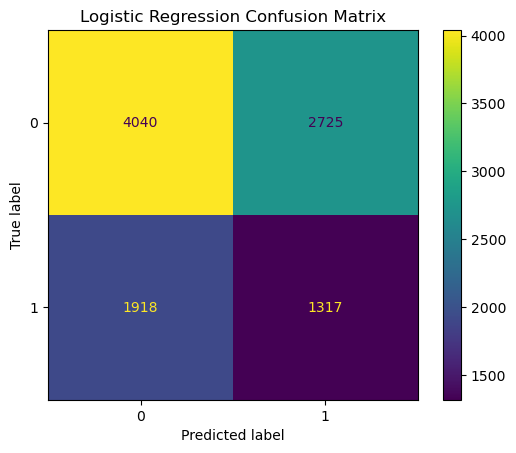

In [32]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(lr, X_test, y_test)
plt.title("Logistic Regression Confusion Matrix")
plt.savefig("lr_confusion_matrix.png")
plt.show()

D:\OneDrive\Desktop\anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
D:\OneDrive\Desktop\anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
 

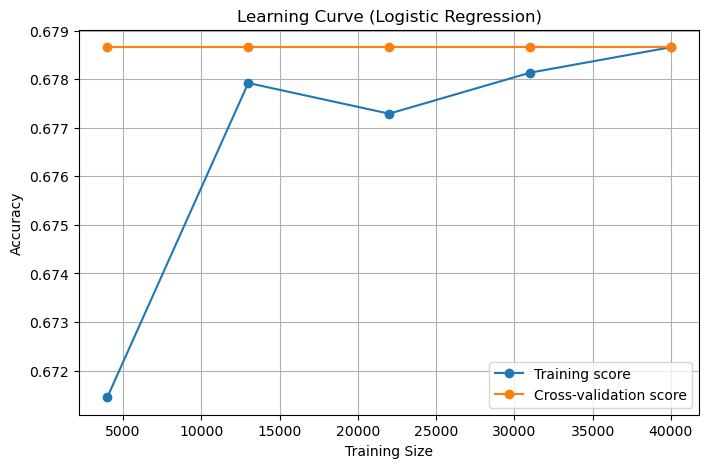

In [33]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Model
model = LogisticRegression(max_iter=1000)

# Generate learning curve data
train_sizes, train_scores, test_scores = learning_curve(
    model, X, y,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5),
    random_state=42
)

# Mean scores
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

# Plot
plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, 'o-', label="Training score")
plt.plot(train_sizes, test_mean, 'o-', label="Cross-validation score")

plt.title("Learning Curve (Logistic Regression)")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

# Save for report
plt.savefig("learning_curve.png")

plt.show()

In [34]:
## Machine Learning Model Training
X = df.drop('Fraud_Label', axis=1)
y = df['Fraud_Label']

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [36]:
##Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [37]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [38]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train_sm, y_train_sm)

y_pred_rf = rf.predict(X_test)

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[6271  494]
 [2993  242]]
              precision    recall  f1-score   support

           0       0.68      0.93      0.78      6765
           1       0.33      0.07      0.12      3235

    accuracy                           0.65     10000
   macro avg       0.50      0.50      0.45     10000
weighted avg       0.56      0.65      0.57     10000



In [39]:
y_prob = rf.predict_proba(X_test)[:,1]

y_pred_custom = (y_prob > 0.4).astype(int)

print(confusion_matrix(y_test, y_pred_custom))
print(classification_report(y_test, y_pred_custom))

[[ 684 6081]
 [ 349 2886]]
              precision    recall  f1-score   support

           0       0.66      0.10      0.18      6765
           1       0.32      0.89      0.47      3235

    accuracy                           0.36     10000
   macro avg       0.49      0.50      0.32     10000
weighted avg       0.55      0.36      0.27     10000



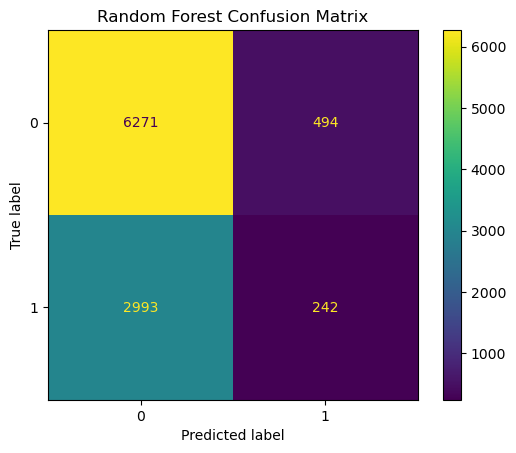

In [40]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)

plt.title("Random Forest Confusion Matrix")

# Save for report
plt.savefig("rf_confusion_matrix.png")

plt.show()

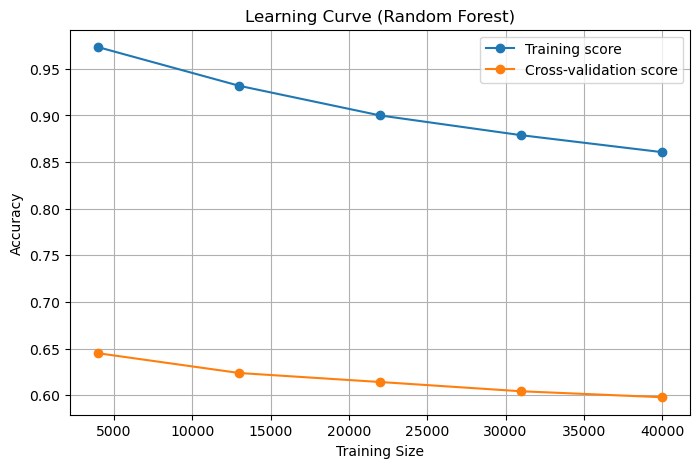

In [41]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# Model
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

# Generate learning curve data
train_sizes, train_scores, test_scores = learning_curve(
    model, X, y,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

# Mean scores
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

# Plot
plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, 'o-', label="Training score")
plt.plot(train_sizes, test_mean, 'o-', label="Cross-validation score")

plt.title("Learning Curve (Random Forest)")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

# Save for report
plt.savefig("rf_learning_curve.png")

plt.show()

In [42]:
df['Fraud_Label'].value_counts()

Fraud_Label
0    33933
1    16067
Name: count, dtype: int64

In [43]:
pip install xgboost


Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



In [44]:
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

xgb.fit(X_train_sm, y_train_sm)

C:\Users\piude\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:200: UserWarning: [12:43:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [45]:
y_pred_xgb = xgb.predict(X_test)

In [46]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

[[6443  322]
 [3111  124]]
              precision    recall  f1-score   support

           0       0.67      0.95      0.79      6765
           1       0.28      0.04      0.07      3235

    accuracy                           0.66     10000
   macro avg       0.48      0.50      0.43     10000
weighted avg       0.55      0.66      0.56     10000



In [47]:
y_prob = xgb.predict_proba(X_test)[:,1]
y_pred_custom = (y_prob > 0.4).astype(int)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.67      0.79      0.72      6765
           1       0.31      0.20      0.24      3235

    accuracy                           0.60     10000
   macro avg       0.49      0.49      0.48     10000
weighted avg       0.55      0.60      0.57     10000



C:\Users\piude\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:200: UserWarning: [12:43:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


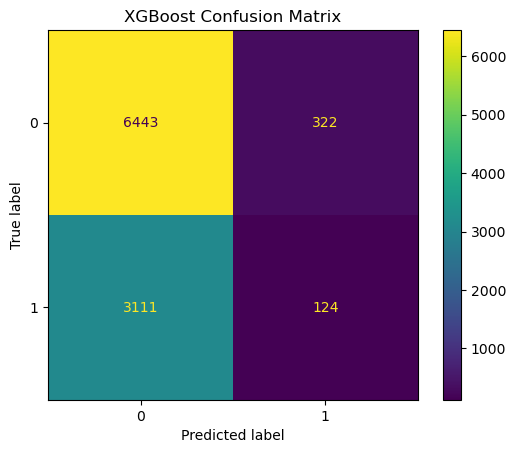

In [48]:
from xgboost import XGBClassifier
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Model
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Train (use SMOTE data)
xgb.fit(X_train_sm, y_train_sm)

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(xgb, X_test, y_test)

plt.title("XGBoost Confusion Matrix")

# Save for report
plt.savefig("xgb_confusion_matrix.png")

plt.show()

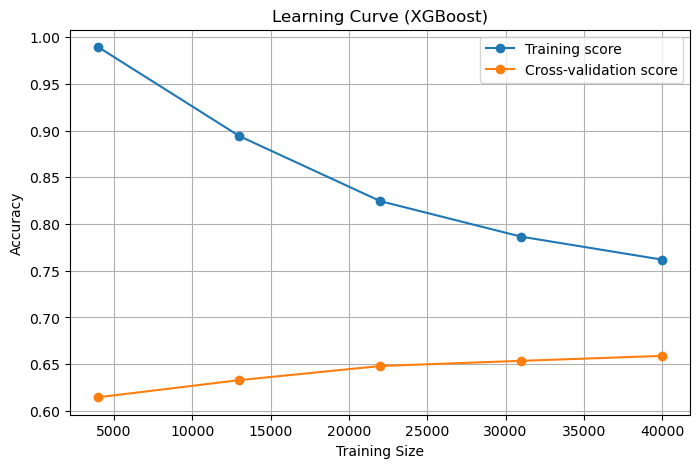

In [49]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

# Model
model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# Generate learning curve data
train_sizes, train_scores, test_scores = learning_curve(
    model, X, y,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

# Mean scores
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

# Plot
plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, 'o-', label="Training score")
plt.plot(train_sizes, test_mean, 'o-', label="Cross-validation score")

plt.title("Learning Curve (XGBoost)")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

# Save for report
plt.savefig("xgb_learning_curve.png")

plt.show()